# Seismic wave propagation in a floating ice sheet — Estimation of the ice and source parameters

2026-02-20 · Cédric Schmelzbach (ETH Zurich), Christoph Wetter (WSL)

Overview

This notebook uses field recordings from Lake St. Moritz (winter 2022) to estimate ice properties (e.g., thickness) and basic source parameters (e.g., distance and source time).
We combine observed $qS$ dispersion, the coincidence frequency between ice and air, and time–frequency picks from seismometer and microphone data to constrain models.

Objectives
* Compute $qS$ dispersion curves for simple elastic-plate models and extract phase/group velocities.
* Identify the coincidence frequency $f_c$ where $qS$ phase velocity matches sound speed in air and compute group velocity at $f_c$
* Use observed ACW timing and $u(f_c)$ to estimate source distance and source time (with clear assumptions).
* Test sensitivity of estimated ice thickness and other elastic parameters.

Reference to data and analyses:
Schmelzbach, C., C. Wetter and S. Stähler (2025), The sound of ice: characterising lake ice using
seismo-acoustic observations, Near Surface Geoscience Conference & Exhibition 2025. 10.3997/2214-
4609.202520265.


In [1]:
import os
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy.signal.rotate import rotate_ne_rt
from obspy import UTCDateTime
from scipy.signal import butter, filtfilt
from obspy import read, read_inventory
from obspy.signal.tf_misfit import cwt
from compute_qs_dispersion import compute_qs_dispersion
from scipy.interpolate import interp1d

# 1 - Sensitivity of the dispersion charactersitics to the ice parameters

To explore the sensitivity of the dispersion curves and the dependence of the air-coupled wave to the ice parameters and air temperature, you will start with computing synthetic dispersion curves.

The cell below allows you to compute (1) the dispersion curve of a $qS$ wave for a given model (solving the equation system by Yu et al. https://doi.org/10.1016/j.csndt.2014.11.001) and (2) extract the coincidence frequency for a given model and air temperature.

To extract the coincidence frequency $f_c$, the frequency at which the phase velocity of the $qS$ waves matches the sound velocity in air (which depends on air temperature) is extracted. At $f_c$, the wavelength in the ice matches the wave lenght in the air. The onset time of the air-coupled wave (see notebook 2) is given by the group velocity at $f_c$ ($u(f_c)$) and the distance between source and receiver.

Change the ice parameters and air temperature below to study their impact on the dispersion curve and $f_c$. As a reference to compare, the solutions for for d = 0.50 m, E = 7.3 GPa, p_ice = 917 kg/m^3, sigma = 0.33, and T = 0°C are displayed with dashed lines.

The temperature-dependent speed of sound in air is compute using:

$c_{air} = 331 \mathrm{m/s} \sqrt{1 + \frac{T_C}{273\mathrm{C}}}$

Try, for example, to change only the ice thickness by +/- 10 cm. 


Air sound speed at 0°C: 331.32 m/s
Calculating QS dispersion curves for d = 0.75 m, E = 7.3 GPa, p_ice = 917 kg/m^3, sigma = 0.33
Coincidence frequency fc: 46.75 Hz
Group velocity at fc: 722.69 m/s
Calculating reference QS dispersion curves for d = 0.50 m, E = 7.3 GPa, p_ice = 917 kg/m^3, sigma = 0.33; reference T = 0°C


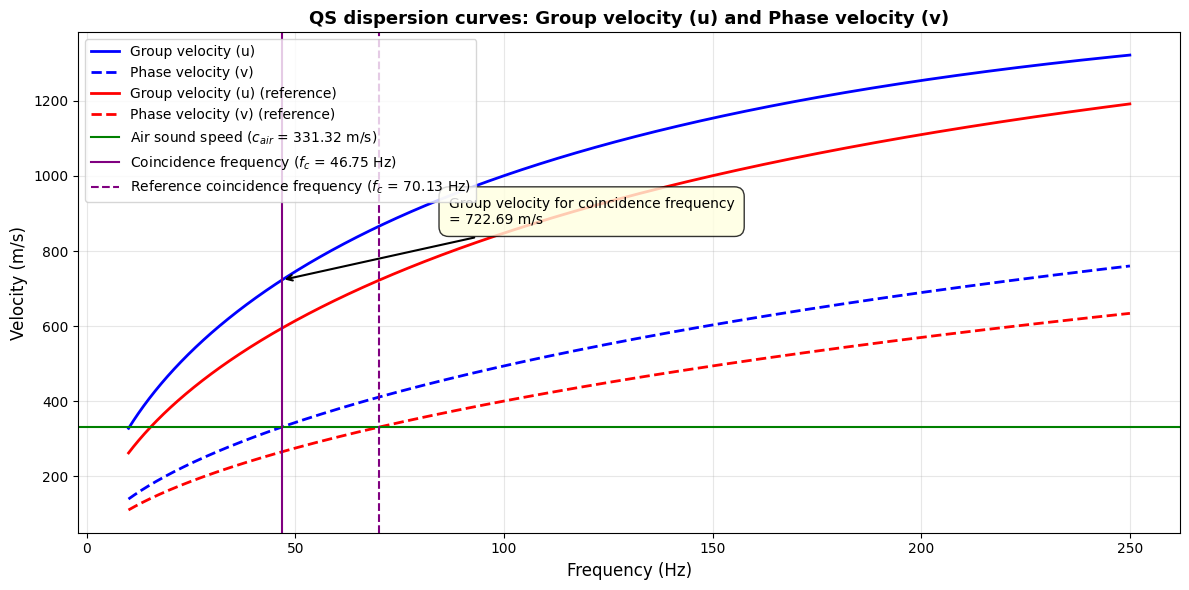

In [2]:
# Set the parameters for the simulations

# Calculate air sound speed as a function of temperature
TC = 0  # Air temperature in Celsius

# Set the ice parameters
d = 0.75 # ice thickness in m
E = 7.3e9 # Young's modulus in Pa
p_ice = 917 # density of ice in kg/m^3
sigma = 0.33 # Poisson's ratio

# Set the frequency range for the dispersion curve calculation
f_min = 10
f_max = 250


# --- No need to change below this line for the current analysis ---

# Compute the air sound speed at the given temperature
c_air = 331.32 * np.sqrt(1 + TC / 273.15)
print(f'Air sound speed at {TC}°C: {c_air:.2f} m/s')

# Calculate QS Group Velocity 
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
print(f'Calculating QS dispersion curves for d = {d:.2f} m, E = {E/1e9:.1f} GPa, p_ice = {p_ice} kg/m^3, sigma = {sigma}')   
freq_vector = np.linspace(f_min, f_max, 10000)
qs_dispersion = compute_qs_dispersion(d=d, E=E, p_ice=p_ice, sigma=sigma, freq=freq_vector)
u1 = qs_dispersion['u']
freq1 = qs_dispersion['freq']

# Create an interpolation function for group velocity
u1_interp = interp1d(freq1, u1, kind='cubic', fill_value='extrapolate')

# Extract phase velocity from qs_dispersion
v_phase = np.real(qs_dispersion['v'])
freq = qs_dispersion['freq']

# Create inverse interpolation from velocity to frequency
v_to_freq_interp = interp1d(v_phase, freq, kind='cubic', fill_value='extrapolate')
freq_at_c_air = v_to_freq_interp(c_air)
print(f'Coincidence frequency fc: {freq_at_c_air:.2f} Hz')

# Compute the group velocity at the observed ACW frequency using interpolation
u1_fc_interp = u1_interp(freq_at_c_air)
print(f'Group velocity at fc: {u1_fc_interp:.2f} m/s')

# Extract data from qs_dispersion
freq = qs_dispersion['freq']
u = qs_dispersion['u']
v = qs_dispersion['v']

# Compute as a reference:
# Set the ice parameters
d_ref = 0.5 # ice thickness in m
E_ref = 7.3e9 # Young's modulus in Pa
p_ice_ref = 917 # density of ice in kg/m^3
sigma_ref = 0.33 # Poisson's ratio
qs_dispersion_reference = compute_qs_dispersion(d=d_ref, E=E_ref, p_ice=p_ice_ref, sigma=sigma_ref, freq=freq_vector)
print(f'Calculating reference QS dispersion curves for d = {d_ref:.2f} m, E = {E_ref/1e9:.1f} GPa, p_ice = {p_ice_ref} kg/m^3, sigma = {sigma_ref}; reference T = 0°C')   

u1_ref = qs_dispersion_reference['u']
v_ref = np.real(qs_dispersion_reference['v'])
freq1_ref = qs_dispersion_reference['freq']

c_air_ref = 331.32 * np.sqrt(1 + 0 / 273.15)
v_to_freq_interp_ref = interp1d(v_ref, freq1_ref, kind='cubic', fill_value='extrapolate')
freq_at_c_air_alt = v_to_freq_interp_ref(c_air_ref)

# Filter out small group velocity values (smaller than 1e-2)
mask = np.abs(u) >= 1e-2
freq_filtered = freq[mask]
u_filtered = u[mask]

mask_ref = np.abs(u1_ref) >= 1e-2
freq1_ref_filtered = freq1_ref[mask_ref]
u1_ref_filtered = u1_ref[mask_ref]

# Create figure with 1 subplot
fig, ax1 = plt.subplots(figsize=(12, 6))

line1 = ax1.plot(freq_filtered, u_filtered, 'b-', linewidth=2, label='Group velocity (u)')
line2 = ax1.plot(freq, np.real(v), 'b--', linewidth=2, label='Phase velocity (v)')

line3 = ax1.plot(freq1_ref_filtered, u1_ref_filtered, 'r-', linewidth=2, label='Group velocity (u) (reference)')
line4 = ax1.plot(freq1_ref, np.real(v_ref), 'r--', linewidth=2, label='Phase velocity (v) (reference)')

ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Velocity (m/s)', fontsize=12)
ax1.set_title('QS dispersion curves: Group velocity (u) and Phase velocity (v)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

lines = line1 + line2 + line3 + line4   
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# Mark the air sound speed on the plot
ax1.axhline(c_air, color='green', linestyle='-', linewidth=1.5, label=f'Air sound speed ($c_{{air}}$ = {c_air:.2f} m/s)')
ax1.legend(loc='upper left', fontsize=10)
# Mark the frequency corresponding to air sound speed on the plot
ax1.axvline(freq_at_c_air, color='purple', linestyle='-', linewidth=1.5, label=f'Coincidence frequency ($f_c$ = {freq_at_c_air:.2f} Hz)')
ax1.axvline(freq_at_c_air_alt, color='purple', linestyle='--', linewidth=1.5, label=f'Reference coincidence frequency ($f_c$ = {freq_at_c_air_alt:.2f} Hz)')
ax1.legend(loc='upper left', fontsize=10)

# Add annotation with arrow pointing to the coincidence frequency point
ax1.annotate(f'Group velocity for coincidence frequency\n= {u1_fc_interp:.2f} m/s',
             xy=(freq_at_c_air, u1_fc_interp),
             xytext=(freq_at_c_air + 40, u1_fc_interp + 150),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.7', facecolor='lightyellow', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.show()

# 2 - Estimation of ice properties from the QS dispersion and coincidence frequency

You will now analyse the field data used in the other notebooks to estimate the ice properties for the selected ice quake.

Run the cell below to read the seismometer and microphone data.

In [3]:
# Run this cell to load the seismic data and set up for plotting the waveforms. You can adjust the time window and back-azimuth as needed for your analysis.

# --- No need to make changes below this line for the user ---
tr_eis10_z = obspy.read('LakeIceExample_CW_EIS10_Z.mseed')
tr_eis10_n = obspy.read('LakeIceExample_CW_EIS10_N.mseed')
tr_eis10_e = obspy.read('LakeIceExample_CW_EIS10_E.mseed')

# Microphone
tr_mic = obspy.read('LakeIceExample_CW_EIS10_Microphone.mseed')

# Set the time window to display (e.g., around the qS0 arrival at ~60s)
window_start_time = 59.75 # in seconds from start of traces
window_end_time = 62.0

# Set the back-azimuth for rotation (degrees)
baz = 41

r, t = rotate_ne_rt(tr_eis10_n[0].data, tr_eis10_e[0].data, baz)
trR = tr_eis10_z.copy(); trT = tr_eis10_z.copy()
trR[0].data = r
trT[0].data = t

# compute global max absolute amplitude across Z, R, T and set symmetric y-limits
all_amps = np.concatenate((np.abs(tr_eis10_z[0].data), np.abs(trR[0].data), np.abs(trT[0].data)))
max_amp = np.max(all_amps) if all_amps.size > 0 else 0.0
ylim = 2.0 * max_amp

# Scaling for microphone plot (optional, adjust as needed)
mic_max_amp = np.max(np.abs(tr_mic[0].data)) if tr_mic[0].data.size > 0 else 0.0
ylim_mic = 2.0 * mic_max_amp



### 2.1 Determine the ACW parameters

Run the cell to compute spectrograms of the microphone data and vertical component data. 

Note how the spectrogram of the microphone data and vertical component correspond to each other for the very first part; both show the the same dispersion curve of the $QS$-mode. 

Either enter the start and end time of the air-coupled wave (`starttime_acw`and `endtime_acw`) and coincidence frequnency (`acw_fc`) from notebook 2 or defined them here.

My preferred values: at around 60.275 s, the microphone observation shows the transition from the dispersive $QS$-mode to the monochromatic ACW wavetrain, with the ACW showing a coincidence frequency of around 59 Hz. 

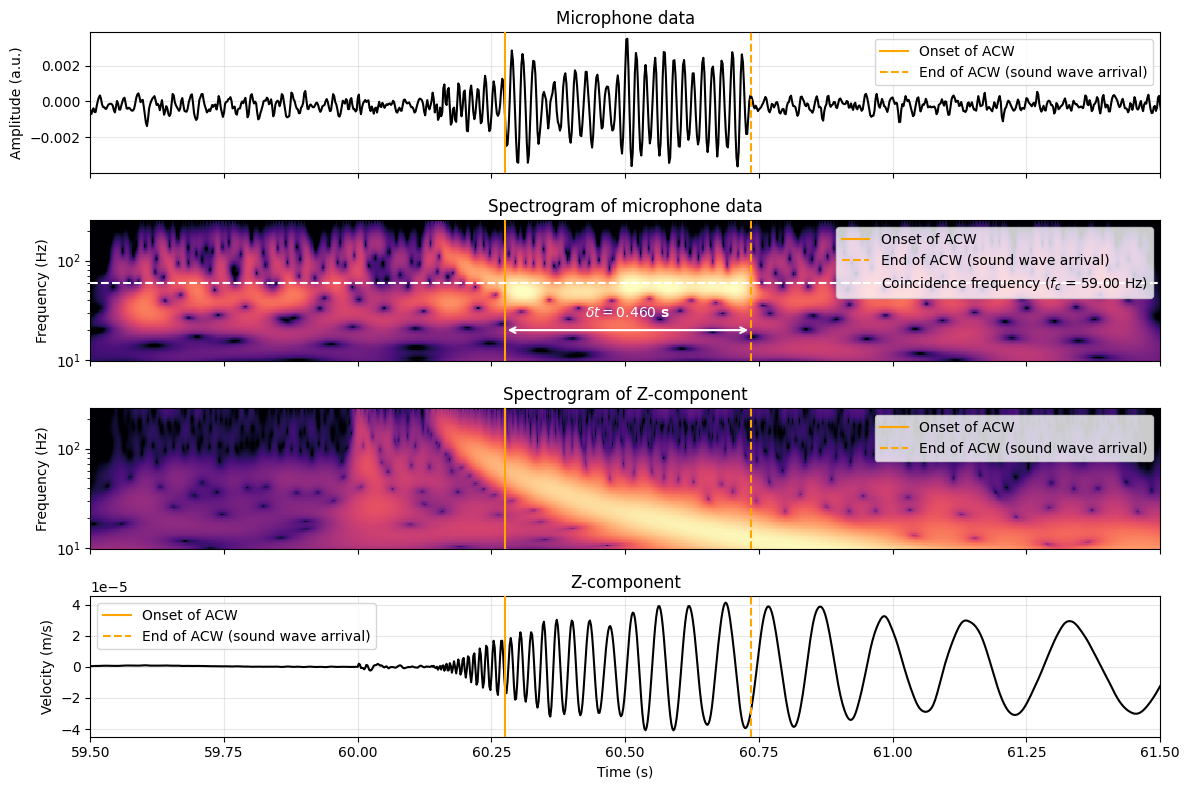

In [4]:
starttime_acw = 60.275 # Arrival time of ACW
endtime_acw = 60.735 # Arrival time of ACW

acw_fc = 59 # Coincidence frequency in Hz

# --- No need to make changes below this line for the user ---

# Trim for more focused time-frequency analysis around the qS0 arrival (e.g., 59-65s)
trace_start_time = 59.5
spectrogram_window = 2.0  # Set the time window duration for the spectrogram (e.g., 6 seconds to cover 59-65s)

# Extract start time
start_time = tr_eis10_z[0].stats.starttime

# Spectrogram of microphone data
tr_trim_mic = tr_mic.copy().trim(start_time + trace_start_time, start_time + trace_start_time + spectrogram_window)
tr_trim_mic.taper(max_percentage=0.05)
npts = tr_trim_mic[0].stats.npts
dt = tr_trim_mic[0].stats.delta
t = np.linspace(0, dt * npts, npts)
f_min = 10
f_max = 250
scalogram_mic = cwt(tr_trim_mic[0].data, dt, 5, f_min, f_max)
x_mic, y_mic = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram_mic.shape[0]))

# Spectrogram of seismic data
tr_trim = tr_eis10_z.copy().trim(start_time + trace_start_time, start_time + trace_start_time + spectrogram_window)
tr_trim.taper(max_percentage=0.05)
npts = tr_trim[0].stats.npts
dt = tr_trim[0].stats.delta
t = np.linspace(0, dt * npts, npts)
scalogram = cwt(tr_trim[0].data, dt, 5, f_min, f_max)
x, y = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram.shape[0]))

# Plotting
fig, axs = plt.subplots(4,1, sharex=True, figsize=(12,8),
                        gridspec_kw={'height_ratios':[1,1,1,1]})  # first axis half the height of second

# Microphone
axs[0].plot(tr_mic[0].times(), tr_mic[0].data, 'k-'); 
axs[0].set_title('Microphone data')
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(trace_start_time, trace_start_time + spectrogram_window)
axs[0].set_ylabel('Amplitude (a.u.)')
axs[0].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[0].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[0].legend()

im = axs[1].pcolormesh(x_mic + trace_start_time, y_mic, np.log10(np.abs(scalogram_mic)), cmap='magma', vmin=-6, vmax=-3.5)
axs[1].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[1].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[1].axhline(acw_fc, color='white', linestyle='--', linewidth=1.5, zorder=5, label=f'Coincidence frequency ($f_{{c}}$ = {acw_fc:.2f} Hz)')
axs[1].set_ylabel("Frequency (Hz)")
axs[1].set_yscale('log')
axs[1].set_title('Spectrogram of microphone data')
# Add a line with arrow heads on both ends at 20 Hz
axs[1].annotate('',
                xy=(endtime_acw, 20),
                xytext=(starttime_acw, 20),
                arrowprops=dict(arrowstyle='<->', color='white', lw=1.5))
# Add text in the center of the arrow
delta_t = endtime_acw - starttime_acw
axs[1].text((starttime_acw + endtime_acw) / 2, 20+5, 
            f'$\\delta t = {delta_t:.3f}$ s',
            ha='center', va='bottom', fontsize=10, color='white', weight='bold')
axs[1].legend()

# Z-component
axs[3].plot(tr_eis10_z[0].times(), tr_eis10_z[0].data, 'k-'); 
axs[3].set_title('Z-component')
axs[3].grid(True, alpha=0.3)
axs[3].set_xlim(trace_start_time, trace_start_time + spectrogram_window)
axs[3].set_ylabel('Velocity (m/s)')
axs[3].set_xlabel("Time (s)")
axs[3].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[3].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[3].legend()

im = axs[2].pcolormesh(x + trace_start_time, y, np.log10(np.abs(scalogram)), cmap='magma', vmin=-10, vmax=-5)
axs[2].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[2].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[2].set_ylabel("Frequency (Hz)")
axs[2].set_yscale('log')
axs[2].set_title('Spectrogram of Z-component')
axs[2].legend()

plt.tight_layout()
plt.show()

### 2.2 Ice parameters

The cell below allows you to compute for a given ice model the coincidence frequency ($f_c$). Use the cell to estimate ice thickness, assuming that the ice elastic parameters and air temperature are approximately known. 

Enter you coincidence frequency estimate from above (`acw_fc`) and change the ice thickness `d` by trial and error such that the observed and modelled $f_c$ match.

Once you have an estimate of the ice thickness, vary firstly temperature and Young's modulus, later the other parameters by a few percent to see the infucence.

During the deployment time, the ice thickness was determined a few times next to the station by drilling:

| Date | Ice thickness (cm) |
|----------|----------|
| 2022-01-19 | 34 $\pm$ 2 |
| 2022-02-03 | 45 $\pm$ 2 |
| 2022-03-01 | 56 $\pm$ 2 |
| 2022-03-28 | 58 $\pm$ 2 |

Air sound speed at 0°C: 331.32 m/s
Calculating QS dispersion curves for d = 0.50 m, E = 7.3 GPa, p_ice = 917 kg/m^3, sigma = 0.33
Group velocity at fc (interpolation): 722.71 m/s
Theoretical coincidence frequency fc: 70.13 Hz
****************************
Observed coincidence frequency fc: 59.00 Hz
****************************


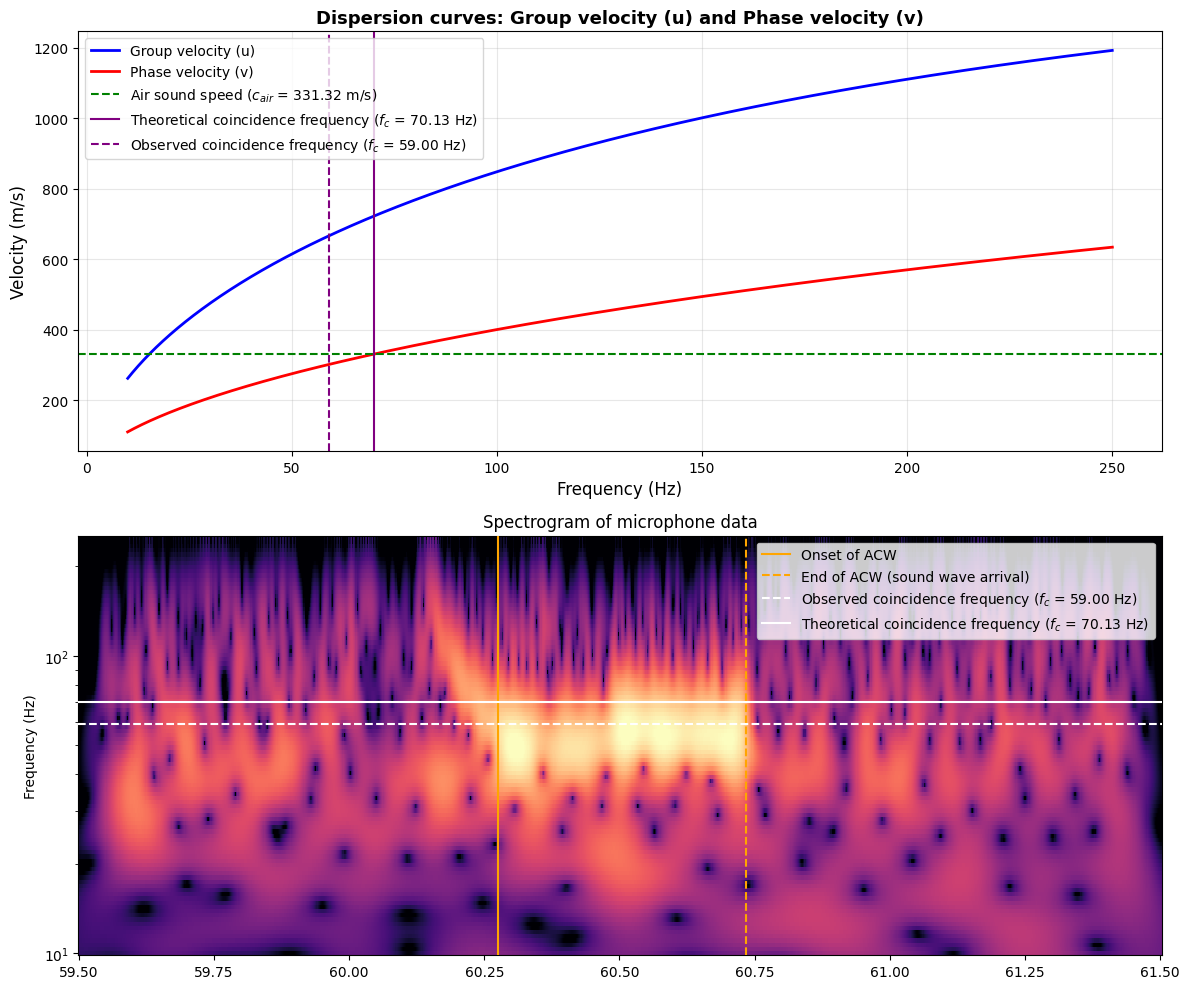

In [5]:
# --- Observed ACW frequency ---
acw_fc = 59 # Coincidence frequency in Hz

#  Optionally set the arrival time of ACW based on your observations. This will be used to mark the ACW in the plots.
# starttime_acw = 60.275 # Arrival time of ACW
# endtime_acw = 60.735 # Arrival time of ACW

# --- Set the parameters for the simulations ---

# To calculate air sound speed as a function of temperature
TC = 0  # Air temperature in Celsius

# Set the ice parameters
d = 0.5 # ice thickness in m
E = 7.3e9 # Young's modulus in Pa
p_ice = 917 # density of ice in kg/m^3
sigma = 0.33 # Poisson's ratio

# Set the frequency range for the dispersion curve calculation
f_min = 10
f_max = 250


# --- No need to change below this line for the current analysis ---
c_air = 331.32 * np.sqrt(1 + TC / 273.15)
print(f'Air sound speed at {TC}°C: {c_air:.2f} m/s')

# Calculate QS Group Velocity 
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
print(f'Calculating QS dispersion curves for d = {d:.2f} m, E = {E/1e9:.1f} GPa, p_ice = {p_ice} kg/m^3, sigma = {sigma}')   
freq_vector = np.linspace(f_min, f_max, 10000)
qs_dispersion = compute_qs_dispersion(d=d, E=E, p_ice=p_ice, sigma=sigma, freq=freq_vector)

# Extract group, phase velocity, and from qs_dispersion
u1 = qs_dispersion['u']
v_phase = np.real(qs_dispersion['v'])
freq = qs_dispersion['freq']

# Create inverse interpolation from velocity to frequency
v_to_freq_interp = interp1d(v_phase, freq, kind='cubic', fill_value='extrapolate')
freq_at_c_air_alt = v_to_freq_interp(c_air)

# Create interpolation function
u1_interp = interp1d(freq, u1, kind='cubic', fill_value='extrapolate')

# Compute the group velocity at the observed ACW frequency using interpolation
u1_fc_interp = u1_interp(freq_at_c_air_alt)
print(f'Group velocity at fc (interpolation): {u1_fc_interp:.2f} m/s')
print(f'Theoretical coincidence frequency fc: {freq_at_c_air_alt:.2f} Hz')
print('****************************')
print(f'Observed coincidence frequency fc: {acw_fc:.2f} Hz')
print('****************************')

# Create figure with 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Filter out small group velocity values (smaller than 1e-2)
mask = np.abs(u1) >= 1e-2
freq_filtered = freq[mask]
u_filtered = u1[mask]

line1 = axs[0].plot(freq_filtered, u_filtered, 'b-', linewidth=2, label='Group velocity (u)')
line2 = axs[0].plot(freq, np.real(v_phase), 'r-', linewidth=2, label='Phase velocity (v)')

axs[0].set_xlabel('Frequency (Hz)', fontsize=12)
axs[0].set_ylabel('Velocity (m/s)', fontsize=12)
axs[0].set_title('Dispersion curves: Group velocity (u) and Phase velocity (v)', fontsize=13, fontweight='bold')
axs[0].grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
axs[0].legend(lines, labels, loc='upper left', fontsize=10)

# Mark the air sound speed on the plot
axs[0].axhline(c_air, color='green', linestyle='--', linewidth=1.5, label=f'Air sound speed ($c_{{air}}$ = {c_air:.2f} m/s)')
axs[0].legend(loc='upper left', fontsize=10)

# Mark the frequency corresponding to air sound speed on the plot
axs[0].axvline(freq_at_c_air_alt, color='purple', linestyle='-', linewidth=1.5, label=f'Theoretical coincidence frequency ($f_c$ = {freq_at_c_air_alt:.2f} Hz)')
axs[0].axvline(acw_fc, color='purple', linestyle='--', linewidth=1.5, label=f'Observed coincidence frequency ($f_c$ = {acw_fc:.2f} Hz)')
axs[0].legend(loc='upper left', fontsize=10)

im = axs[1].pcolormesh(x_mic + trace_start_time, y_mic, np.log10(np.abs(scalogram_mic)), cmap='magma', vmin=-6, vmax=-3.5)
axs[1].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[1].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[1].axhline(acw_fc, color='white', linestyle='--', linewidth=1.5, zorder=5, label=f'Observed coincidence frequency ($f_{{c}}$ = {acw_fc:.2f} Hz)')
axs[1].axhline(freq_at_c_air_alt, color='white', linestyle='-', linewidth=1.5, zorder=5, label=f'Theoretical coincidence frequency ($f_{{c}}$ = {freq_at_c_air_alt:.2f} Hz)')
axs[1].set_ylabel("Frequency (Hz)")
axs[1].set_yscale('log')
axs[1].set_title('Spectrogram of microphone data')
axs[1].legend()

plt.tight_layout()
plt.show()


### 2.3 Source parameter estimation

Let's assume you found a useful ice thickness (and possibly ice elastic parameters) in the cell above. You will now use these parameters to compute the distance from the receiver (microphone) to the source based in the duration of the ACW:

$\delta t = t_2 - t_1 = \delta x \left(\frac{1}{c_{air}} - \frac{1}{u(f_c)} \right)$,

where $\delta t$ is the time difference between the beginning and the end of the ACW, $\delta x$ is the distance between the source and the receiver.

Once the distance to the source $\delta x$ is known, the arrival time of the individual components of the dispersive $qS$ arrival can be computed using the frequency-dependent group velocity.

Furthermore, the source time $t_0$ can be computed using, for example the arrival times $t_1$ or $t_2$ and $u(f_c)$ or $c_{air}$, respectively.

Air sound speed at 0°C: 331.32 m/s
Calculating QS dispersion curves for d = 0.63 m, E = 7.3 GPa, p_ice = 917 kg/m^3, sigma = 0.33
Group velocity at fc (interpolation): 742.52 m/s
Modelled coincidence frequency fc: 55.66 Hz
Observed coincidence frequency fc: 59.00 Hz
Observed ACW duration: 0.46 s
--------------------
Estimated distance to source: 275.21 m
Estimated source time: 59.90 s
--------------------


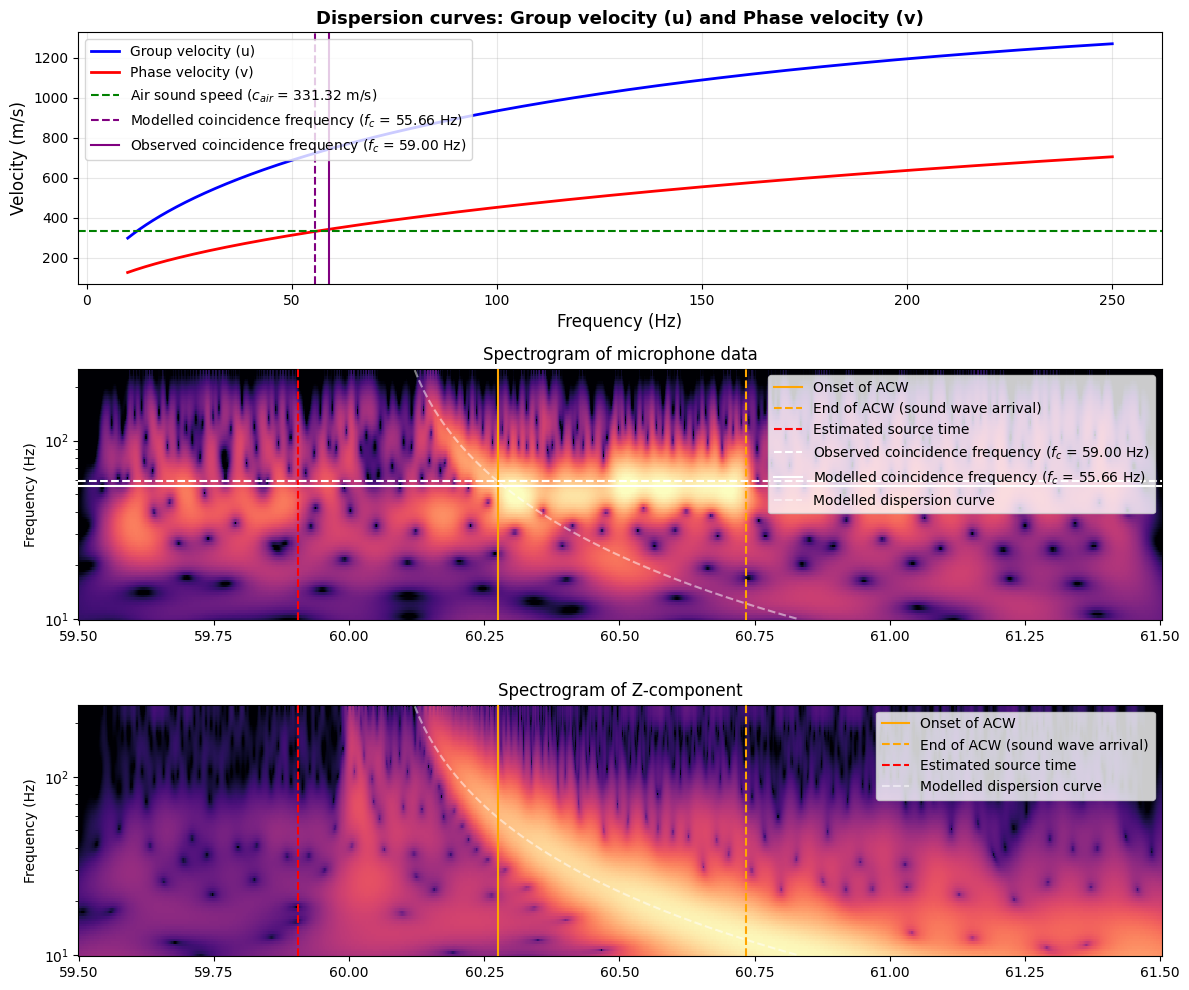

In [6]:
# --- Observed ACW frequency ---
acw_fc = 59 # Coincidence frequency in Hz

#  --- Observed ACW start and end times ---
starttime_acw = 60.275 # Arrival time of ACW
endtime_acw = 60.735 # Arrival time of ACW

# --- Set the parameters for the modelling ---

# Calculate air sound speed as a function of temperature
TC = 0  # Air temperature in Celsius

# Set the ice parameters
d = 0.63 # ice thickness in m
E = 7.3e9 # Young's modulus in Pa
p_ice = 917 # density of ice in kg/m^3
sigma = 0.33 # Poisson's ratio

# Set the frequency range for the dispersion curve calculation
f_min = 10
f_max = 250


# --- No need to change below this line for the current analysis ---

c_air = 331.32 * np.sqrt(1 + TC / 273.15)
print(f'Air sound speed at {TC}°C: {c_air:.2f} m/s')

# Calculate QS Group Velocity 
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
print(f'Calculating QS dispersion curves for d = {d:.2f} m, E = {E/1e9:.1f} GPa, p_ice = {p_ice} kg/m^3, sigma = {sigma}')   
freq_vector = np.linspace(f_min, f_max, 10000)
qs_dispersion = compute_qs_dispersion(d=d, E=E, p_ice=p_ice, sigma=sigma, freq=freq_vector)
u1 = qs_dispersion['u']
freq1 = qs_dispersion['freq']

# Create interpolation function
u1_interp = interp1d(freq1, u1, kind='cubic', fill_value='extrapolate')

# Compute the group velocity at the observed ACW frequency using interpolation
u1_fc_interp = u1_interp(acw_fc)
print(f'Group velocity at fc (interpolation): {u1_fc_interp:.2f} m/s')

# Extract phase velocity from qs_dispersion
v_phase = np.real(qs_dispersion['v'])
freq = qs_dispersion['freq']

# # Create inverse interpolation from velocity to frequency
v_to_freq_interp = interp1d(v_phase, freq, kind='cubic', fill_value='extrapolate')
freq_at_c_air_alt = v_to_freq_interp(c_air)
print(f'Modelled coincidence frequency fc: {freq_at_c_air_alt:.2f} Hz')
# print(f'Observed coincidence frequency fc: {acw_fc:.2f} Hz')


# --- Compute source parameters based on fc and u estimate ---
d_vel = (1/c_air - 1/u1_fc_interp)
d_time = endtime_acw - starttime_acw
dist = d_time / d_vel
time_0_air = endtime_acw - dist / c_air
time_0_qs_fc = starttime_acw - dist / u1_fc_interp

# Some information on source
print(f'Observed coincidence frequency fc: {acw_fc:.2f} Hz')
print(f'Observed ACW duration: {d_time:.2f} s')
print('--------------------')
print(f'Estimated distance to source: {dist:.2f} m')
print(f'Estimated source time: {time_0_air:.2f} s')
# print(f'Estimated source time: {time_0_qs_fc:.2f} s')
print('--------------------')

# Create figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Filter out small group velocity values (smaller than 1e-2)
mask = np.abs(u1) >= 1e-2
freq_filtered = freq1[mask]
u_filtered = u1[mask]

line1 = axs[0].plot(freq_filtered, u_filtered, 'b-', linewidth=2, label='Group velocity (u)')
line2 = axs[0].plot(freq, np.real(v_phase), 'r-', linewidth=2, label='Phase velocity (v)')

axs[0].set_xlabel('Frequency (Hz)', fontsize=12)
axs[0].set_ylabel('Velocity (m/s)', fontsize=12)
axs[0].set_title('Dispersion curves: Group velocity (u) and Phase velocity (v)', fontsize=13, fontweight='bold')
axs[0].grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
axs[0].legend(lines, labels, loc='upper left', fontsize=10)

# Mark the air sound speed on the plot
axs[0].axhline(c_air, color='green', linestyle='--', linewidth=1.5, label=f'Air sound speed ($c_{{air}}$ = {c_air:.2f} m/s)')
axs[0].legend(loc='upper left', fontsize=10)
# Mark the frequency corresponding to air sound speed on the plot
axs[0].axvline(freq_at_c_air_alt, color='purple', linestyle='--', linewidth=1.5, label=f'Modelled coincidence frequency ($f_c$ = {freq_at_c_air_alt:.2f} Hz)')
axs[0].axvline(acw_fc, color='purple', linestyle='-', linewidth=1.5, label=f'Observed coincidence frequency ($f_c$ = {acw_fc:.2f} Hz)')
axs[0].legend(loc='upper left', fontsize=10)

im = axs[1].pcolormesh(x_mic + trace_start_time, y_mic, np.log10(np.abs(scalogram_mic)), cmap='magma', vmin=-6, vmax=-3.5)
axs[1].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[1].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[1].axvline(time_0_air, color='red', linestyle='--', linewidth=1.5, zorder=5, label='Estimated source time')
axs[1].axhline(acw_fc, color='white', linestyle='--', linewidth=1.5, zorder=5, label=f'Observed coincidence frequency ($f_{{c}}$ = {acw_fc:.2f} Hz)')
axs[1].axhline(freq_at_c_air_alt, color='white', linestyle='-', linewidth=1.5, zorder=5, label=f'Modelled coincidence frequency ($f_{{c}}$ = {freq_at_c_air_alt:.2f} Hz)')
axs[1].semilogy(dist/u1 + time_0_air, freq1,c='w',ls='--', lw=1.5,alpha=0.5, label='Modelled dispersion curve')
axs[1].set_ylabel("Frequency (Hz)")
axs[1].set_yscale('log')
axs[1].set_title('Spectrogram of microphone data')
axs[1].legend()

im = axs[2].pcolormesh(x + trace_start_time, y, np.log10(np.abs(scalogram)), cmap='magma', vmin=-10, vmax=-5)
axs[2].axvline(starttime_acw, color='orange', linestyle='-', linewidth=1.5, zorder=5, label='Onset of ACW')
axs[2].axvline(endtime_acw, color='orange', linestyle='--', linewidth=1.5, zorder=5, label='End of ACW (sound wave arrival)')
axs[2].axvline(time_0_air, color='red', linestyle='--', linewidth=1.5, zorder=5, label='Estimated source time')
axs[2].semilogy(dist/u1 + time_0_air, freq1,c='w',ls='--', lw=1.5,alpha=0.5, label='Modelled dispersion curve')
axs[2].set_ylabel("Frequency (Hz)")
axs[2].set_yscale('log')
axs[2].set_title('Spectrogram of Z-component')
axs[2].legend()

plt.tight_layout()
plt.show()